# Detecting Point, Contextual, and Collective Anomalies in Time-Series

This notebook demonstrates three common anomaly types:

1. **Point anomalies** — one unusual observation.
2. **Contextual anomalies** — a value that is unusual only given its time/seasonal context.
3. **Collective anomalies** — a sequence of observations that forms an unusual pattern.


## 1. Imports

Run this cell first. If a package is missing, install it using:

```python
!pip install numpy pandas matplotlib statsmodels scikit-learn
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest

np.random.seed(7)


## 2. Create Synthetic Time-Series Examples

We create three separate time-series, each containing one type of anomaly.


In [2]:
t = np.arange(100)

# Point anomaly: one isolated spike
y_point = np.sin(t / 8) + np.random.normal(0, 0.12, size=len(t))
y_point[55] += 3.0

# Contextual anomaly: value is unusual for its seasonal context
y_context = 10 + 0.04 * t + 2 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 0.2, size=len(t))
context_idx = 18
y_context[context_idx] = 12.5

# Collective anomaly: a whole segment follows an unusual pattern
y_collective = np.sin(t / 8) + np.random.normal(0, 0.12, size=len(t))
start, end = 45, 62
y_collective[start:end] = 0.15 * np.sin(np.arange(end - start) * 3) + 1.2


## 3. Helper Plot Function

In [3]:
def plot_series(series, title):
    series = pd.Series(series)

    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values, marker="o", markersize=3)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()


def plot_anomalies(series, anomalies, title):
    series = pd.Series(series)
    anomalies = pd.Series(anomalies, index=series.index)

    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values, label="Time series")
    plt.scatter(
        series.index[anomalies],
        series[anomalies],
        s=80,
        label="Detected anomalies"
    )
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


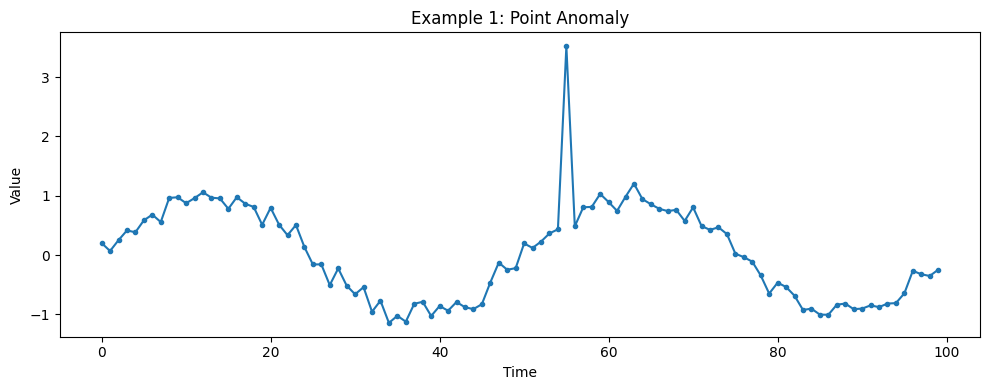

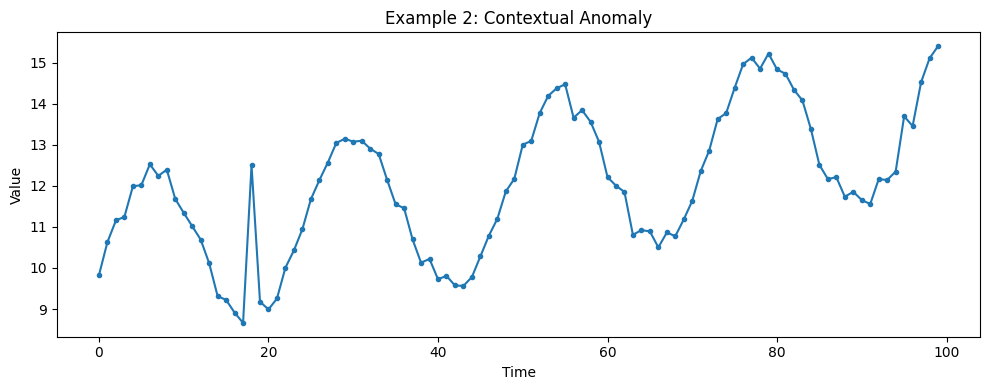

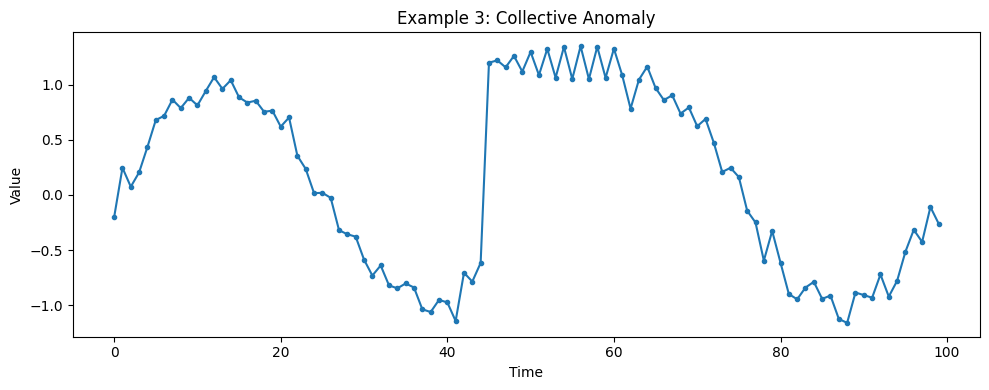

In [4]:
plot_series(y_point, "Example 1: Point Anomaly")
plot_series(y_context, "Example 2: Contextual Anomaly")
plot_series(y_collective, "Example 3: Collective Anomaly")


# 4. Point Anomaly Detection

A **point anomaly** is a single value that is unusually high or low.

A common detection method is the **rolling z-score**:

\[
z_t = \frac{x_t - \mu_t}{\sigma_t}
\]

where \(\mu_t\) and \(\sigma_t\) are computed over a local rolling window.


In [5]:
def detect_point_anomalies(series, window=20, threshold=3):
    series = pd.Series(series)

    rolling_mean = series.rolling(window=window, center=True).mean()
    rolling_std = series.rolling(window=window, center=True).std()

    z_score = (series - rolling_mean) / rolling_std
    anomalies = np.abs(z_score) > threshold

    return anomalies.fillna(False), z_score


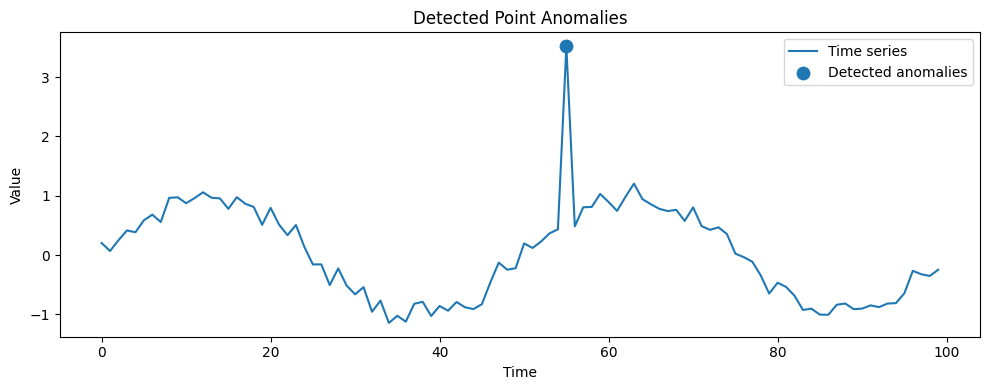

Detected point anomaly indices:
[55]


In [6]:
point_anomalies, point_z_scores = detect_point_anomalies(
    y_point,
    window=20,
    threshold=2.5
)

plot_anomalies(y_point, point_anomalies, "Detected Point Anomalies")
print("Detected point anomaly indices:")
print(np.where(point_anomalies)[0])


# 5. Contextual Anomaly Detection

A **contextual anomaly** is not necessarily extreme globally.  
It is unusual relative to its **trend**, **seasonality**, or local context.

A common approach:

1. Decompose the series using **STL**.
2. Extract the residual component.
3. Apply z-score detection to the residuals.


In [7]:
def detect_contextual_anomalies(series, period, threshold=3):
    series = pd.Series(series)

    stl = STL(series, period=period, robust=True)
    result = stl.fit()

    residuals = result.resid
    residual_mean = residuals.mean()
    residual_std = residuals.std()

    z_score = (residuals - residual_mean) / residual_std
    anomalies = np.abs(z_score) > threshold

    return anomalies.fillna(False), residuals, result


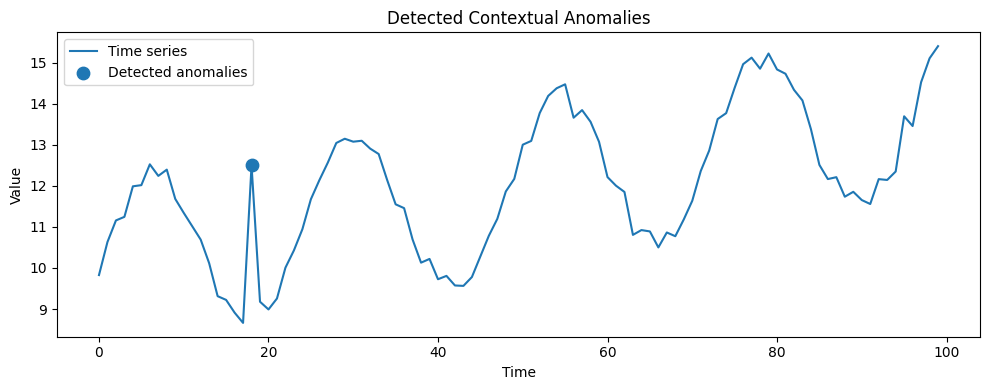

Detected contextual anomaly indices:
[18]


In [8]:
contextual_anomalies, residuals, stl_result = detect_contextual_anomalies(
    y_context,
    period=24,
    threshold=2.5
)

plot_anomalies(y_context, contextual_anomalies, "Detected Contextual Anomalies")
print("Detected contextual anomaly indices:")
print(np.where(contextual_anomalies)[0])


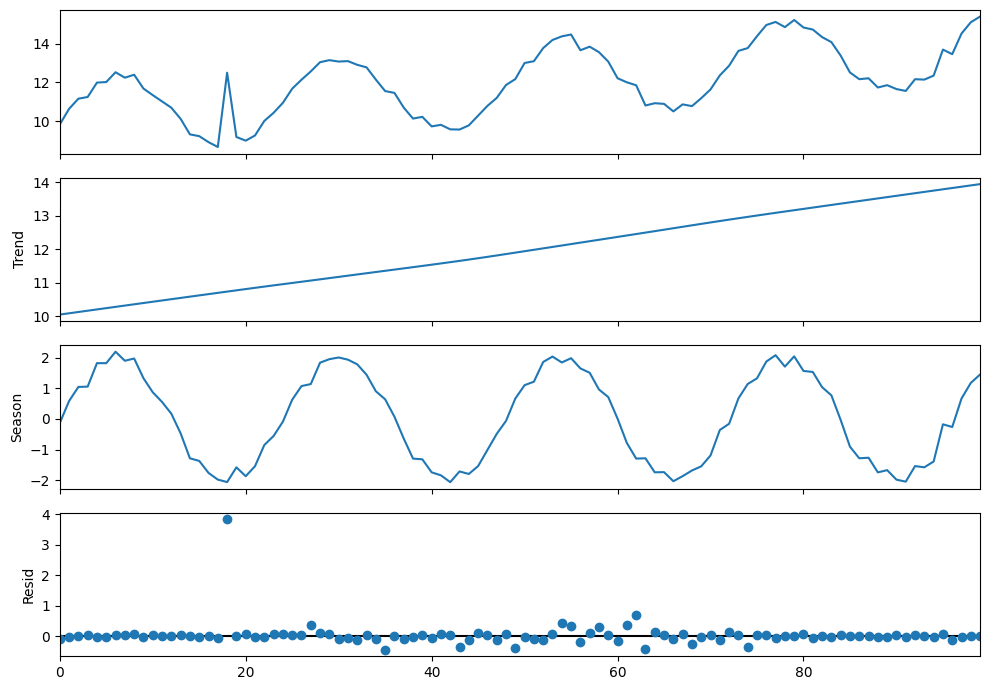

In [9]:
# Optional: visualize STL decomposition
fig = stl_result.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()


# 6. Collective Anomaly Detection

A **collective anomaly** is a group of observations that is unusual as a segment.

Instead of testing each point independently, we create rolling-window features:

- Mean
- Standard deviation
- Minimum
- Maximum
- Average slope

Then we apply **Isolation Forest** to detect abnormal windows.


In [10]:
def detect_collective_anomalies(series, window=10, contamination=0.05):
    series = pd.Series(series)

    features = pd.DataFrame({
        "mean": series.rolling(window).mean(),
        "std": series.rolling(window).std(),
        "min": series.rolling(window).min(),
        "max": series.rolling(window).max(),
        "slope": series.diff().rolling(window).mean()
    }).dropna()

    model = IsolationForest(
        contamination=contamination,
        random_state=42
    )

    labels = model.fit_predict(features)
    window_anomalies = labels == -1

    anomalies = pd.Series(False, index=series.index)

    for idx in features.index[window_anomalies]:
        end_pos = series.index.get_loc(idx)
        start_pos = max(0, end_pos - window + 1)
        anomalies.iloc[start_pos:end_pos + 1] = True

    return anomalies, features, labels


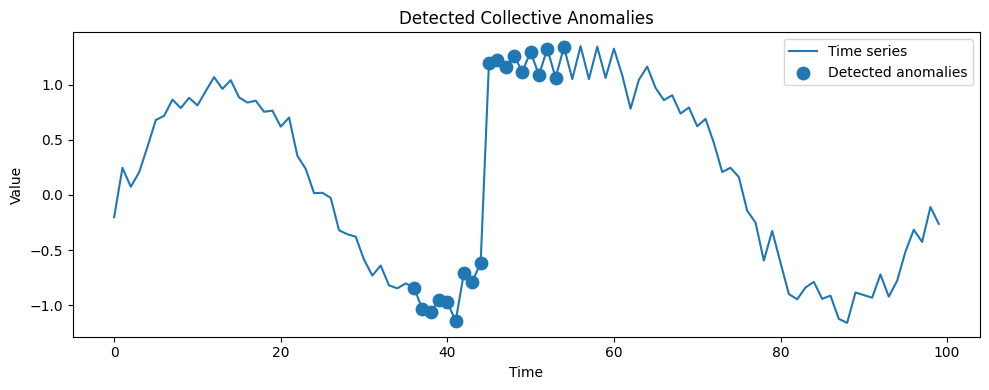

Detected collective anomaly indices:
[36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54]


In [11]:
collective_anomalies, window_features, collective_labels = detect_collective_anomalies(
    y_collective,
    window=10,
    contamination=0.08
)

plot_anomalies(y_collective, collective_anomalies, "Detected Collective Anomalies")
print("Detected collective anomaly indices:")
print(np.where(collective_anomalies)[0])


## 7. Summary

| Anomaly type | Detection strategy |
|---|---|
| Point anomaly | Rolling z-score |
| Contextual anomaly | STL decomposition + residual outlier detection |
| Collective anomaly | Rolling-window features + Isolation Forest |

In real data, parameter tuning is important:

- `window`
- `threshold`
- `period`
- `contamination`
